In [1]:
import os
import numpy as np
import pandas as pd
import sys
from pathlib import Path
from src.prometheus_io import prom_query_range, prom_query_instant, test_connection
import src.prometheus_io as pio
from datetime import datetime, timezone, timedelta
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../exports/intensive_messaging_eda.csv')
df

,timestamp,cpu_by_svc__series_0 {'container_label_com_docker_swarm_task_name': 'chat-eda_cadvisor.2psgdvtnhtcce9zjn6nhcv2x8.wpin3ihy791252iasqz33mdut'},cpu_by_svc__series_1 {'container_label_com_docker_swarm_task_name': 'chat-eda_cadvisor.gkxfmk0f14ry4f8cex3726nm9.y7d1fqu3d7xsuoclz1u02yue3'},cpu_by_svc__series_2 {'container_label_com_docker_swarm_task_name': 'chat-eda_cadvisor.m7evt2fhzisw4dshpe9gae22s.qtk8iq8d4uf6e3yf0p57u63ds'},cpu_by_svc__series_3 {'container_label_com_docker_swarm_task_name': 'chat-eda_cadvisor.r0dh5upwj4tebg66ket20fv8l.q73zpyknxw52k6oci1o6v5867'},cpu_by_svc__series_4 {'container_label_com_docker_swarm_task_name': 'chat-eda_elasticsearch.1.txigtfegc9omf5nc0y72xdeut'},cpu_by_svc__series_5 {'container_label_com_docker_swarm_task_name': 'chat-eda_gateway.1.sx0612atjlb5igu7473leonej'},cpu_by_svc__series_6 {'container_label_com_docker_swarm_task_name': 'chat-eda_gateway.2.xd865yjjnuvytuhynh4hneikv'},cpu_by_svc__series_7 {'container_label_com_docker_swarm_task_name': 'chat-eda_gateway.3.vdkjxqgkpx83diz0zva6mu3pf'},cpu_by_svc__series_8 {'container_label_com_docker_swarm_task_name': 'chat-eda_kafka.1.qlew0xaa5ngrdsswvg1hx4rxk'},...,mem_by_svc__series_20 {'container_label_com_docker_swarm_task_name': 'chat-eda_ws-service.3.0nlz9c4uj5r0bt3rnjkippxpa'},"ws_active_sessions__chat_ws_active_sessions {'instance': '10.0.1.45:8081', 'job': 'ws-service'}","ws_active_sessions__chat_ws_active_sessions {'instance': '10.0.1.47:8081', 'job': 'ws-service'}","ws_active_sessions__chat_ws_active_sessions {'instance': '10.0.1.50:8081', 'job': 'ws-service'}","ws_users__chat_ws_active_users {'instance': '10.0.1.45:8081', 'job': 'ws-service'}","ws_users__chat_ws_active_users {'instance': '10.0.1.47:8081', 'job': 'ws-service'}","ws_users__chat_ws_active_users {'instance': '10.0.1.50:8081', 'job': 'ws-service'}",vus_http_senders__series_0 {},vus_ws_receivers__series_0 {},ws_lat__k6_ws_delivery_latency_ms_p95 {'scenario': 'ws_receivers'}
0,2026-04-29 15:47:44.434000015+00:00,0.045322,0.018372,0.035759,0.067920,0.020883,0.0,0.0,0.0,0.535328,...,374448128.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
1,2026-04-29 15:47:49.434000015+00:00,0.044755,0.018372,0.034907,0.067920,0.020883,0.0,0.0,0.0,0.533778,...,374448128.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
2,2026-04-29 15:47:54.434000015+00:00,0.044755,0.018372,0.034907,0.068530,0.020927,0.0,0.0,0.0,0.533778,...,374448128.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
3,2026-04-29 15:47:59.434000015+00:00,0.047191,0.018426,0.036700,0.068530,0.020927,0.0,0.0,0.0,0.532130,...,374452224.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
4,2026-04-29 15:48:04.434000015+00:00,0.047191,0.018426,0.036700,0.068564,0.020187,0.0,0.0,0.0,0.532130,...,374452224.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
356,2026-04-29 16:17:24.434000015+00:00,0.045706,0.018242,0.038319,0.065379,0.016964,0.0,0.0,0.0,0.528866,...,406212608.0,0.0,0.0,0.0,0.0,0.0,0.0,-5.0,36.0,629.0
357,2026-04-29 16:17:29.434000015+00:00,0.045592,0.018538,0.038685,0.065379,0.016964,0.0,0.0,0.0,0.529890,...,406212608.0,0.0,0.0,0.0,0.0,0.0,0.0,-5.0,32.0,629.0
358,2026-04-29 16:17:34.434000015+00:00,0.045592,0.018538,0.038685,0.065060,0.016797,0.0,0.0,0.0,0.529890,...,406212608.0,0.0,0.0,0.0,0.0,0.0,0.0,-5.0,27.0,629.0
359,2026-04-29 16:17:39.434000015+00:00,0.045342,0.017962,0.038535,0.065060,0.016797,0.0,0.0,0.0,0.530960,...,406216704.0,0.0,0.0,0.0,0.0,0.0,0.0,-5.0,23.0,629.0


In [3]:
# Prepare plotting series from the loaded CSV DataFrame (`df`).
# Supports both long format [metric,timestamp,series,value] and wide format.
if {"metric", "timestamp", "series", "value"}.issubset(df.columns):
    wide_df = (
        df.assign(col_name=df["metric"].astype(str) + "__" + df["series"].astype(str))
          .pivot_table(index="timestamp", columns="col_name", values="value", aggfunc="first")
    )
else:
    wide_df = df.copy()
    if "timestamp" in wide_df.columns:
        wide_df = wide_df.set_index("timestamp")

wide_df.index = pd.to_datetime(wide_df.index, utc=True, errors="coerce")
wide_df = wide_df[~wide_df.index.isna()].sort_index()


def _pick_first_series_frame(candidates):
    lower_cols = {str(c).lower(): c for c in wide_df.columns}
    for token in candidates:
        token_l = token.lower()
        for lc, orig in lower_cols.items():
            if token_l in lc:
                return wide_df[[orig]].dropna()
    return pd.DataFrame(index=wide_df.index)


# Variables used by plotting cells below.
ws_active_sessions = _pick_first_series_frame(["ws_active_sessions"])
ws_users = _pick_first_series_frame(["ws_active_users", "ws_users"])
vus_http_senders = _pick_first_series_frame(["vus_http_senders", "http_senders", "scenario_active_vus"])
ws_service_1_cpu = _pick_first_series_frame(["ws_service_1_cpu", "ws-service.1"])
ws_service_2_cpu = _pick_first_series_frame(["ws_service_2_cpu", "ws-service.2"])
ws_service_3_cpu = _pick_first_series_frame(["ws_service_3_cpu", "ws-service.3"])
ws_lat = _pick_first_series_frame(["ws_delivery_latency", "ws_lat", "delivery_latency"])


def normalize(frame):
    s = frame.iloc[:, 0]
    denom = (s.max() - s.min())
    if denom == 0:
        return s * 0
    return (s - s.min()) / denom

print("Selected columns from loaded df:")
print("- ws_active_sessions:", list(ws_active_sessions.columns) if not ws_active_sessions.empty else "NOT FOUND")
print("- ws_users:", list(ws_users.columns) if not ws_users.empty else "NOT FOUND")
print("- vus_http_senders:", list(vus_http_senders.columns) if not vus_http_senders.empty else "NOT FOUND")
print("- ws_service_1_cpu:", list(ws_service_1_cpu.columns) if not ws_service_1_cpu.empty else "NOT FOUND")
print("- ws_service_2_cpu:", list(ws_service_2_cpu.columns) if not ws_service_2_cpu.empty else "NOT FOUND")
print("- ws_service_3_cpu:", list(ws_service_3_cpu.columns) if not ws_service_3_cpu.empty else "NOT FOUND")
print("- ws_lat:", list(ws_lat.columns) if not ws_lat.empty else "NOT FOUND")

Selected columns from loaded df:
- ws_active_sessions: ["ws_active_sessions__chat_ws_active_sessions {'instance': '10.0.1.45:8081', 'job': 'ws-service'}"]
- ws_users: ["ws_users__chat_ws_active_users {'instance': '10.0.1.45:8081', 'job': 'ws-service'}"]
- vus_http_senders: ['vus_http_senders__series_0 {}']
- ws_service_1_cpu: ["cpu_by_svc__series_18 {'container_label_com_docker_swarm_task_name': 'chat-eda_ws-service.1.jmcosrc6aab2d57aczp8wlrhm'}"]
- ws_service_2_cpu: ["cpu_by_svc__series_19 {'container_label_com_docker_swarm_task_name': 'chat-eda_ws-service.2.t9mk1z4iwwtgw31rwyzhag6ik'}"]
- ws_service_3_cpu: ["cpu_by_svc__series_20 {'container_label_com_docker_swarm_task_name': 'chat-eda_ws-service.3.0nlz9c4uj5r0bt3rnjkippxpa'}"]
- ws_lat: ["ws_lat__k6_ws_delivery_latency_ms_p95 {'scenario': 'ws_receivers'}"]


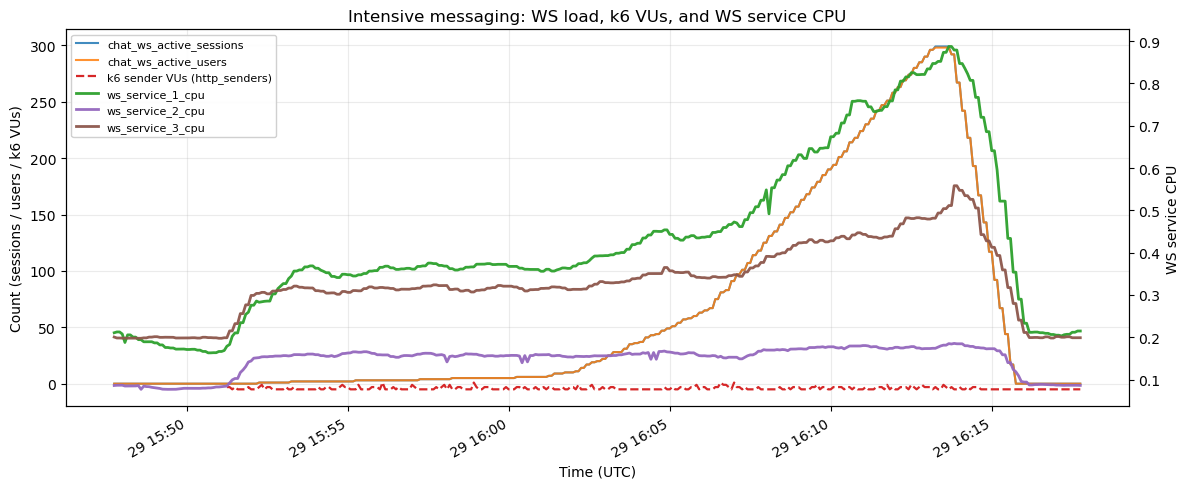

In [4]:
# Left: server metrics + k6 VUs | Right: WS service CPU (both instances)
fig, ax1 = plt.subplots(figsize=(12, 5))

if not ws_active_sessions.empty:
    ws_active_sessions.iloc[:, 0].plot(ax=ax1, color="tab:blue", label="chat_ws_active_sessions", alpha=0.85)

if not ws_users.empty:
    ws_users.iloc[:, 0].plot(ax=ax1, color="tab:orange", label="chat_ws_active_users", alpha=0.85)

if not vus_http_senders.empty:
    vus_http_senders.iloc[:, 0].plot(
        ax=ax1, color="tab:red", linestyle="--", linewidth=1.6, label="k6 sender VUs (http_senders)"
    )

ax1.set_xlabel("Time (UTC)")
ax1.set_ylabel("Count (sessions / users / k6 VUs)")
ax1.set_title("Intensive messaging: WS load, k6 VUs, and WS service CPU")
ax1.grid(True, alpha=0.25)

ax2 = ax1.twinx()
if not ws_service_1_cpu.empty:
    ws_service_1_cpu.iloc[:, 0].plot(ax=ax2, color="tab:green", label="ws_service_1_cpu", linewidth=2.0, alpha=0.95)
if not ws_service_2_cpu.empty:
    ws_service_2_cpu.iloc[:, 0].plot(ax=ax2, color="tab:purple", label="ws_service_2_cpu", linewidth=2.0, alpha=0.95)
if not ws_service_3_cpu.empty:
    ws_service_3_cpu.iloc[:, 0].plot(ax=ax2, color="tab:brown", label="ws_service_3_cpu", linewidth=2.0, alpha=0.95)
ax2.set_ylabel("WS service CPU")

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper left", framealpha=0.92, fontsize=8)

fig.tight_layout()
plt.show()

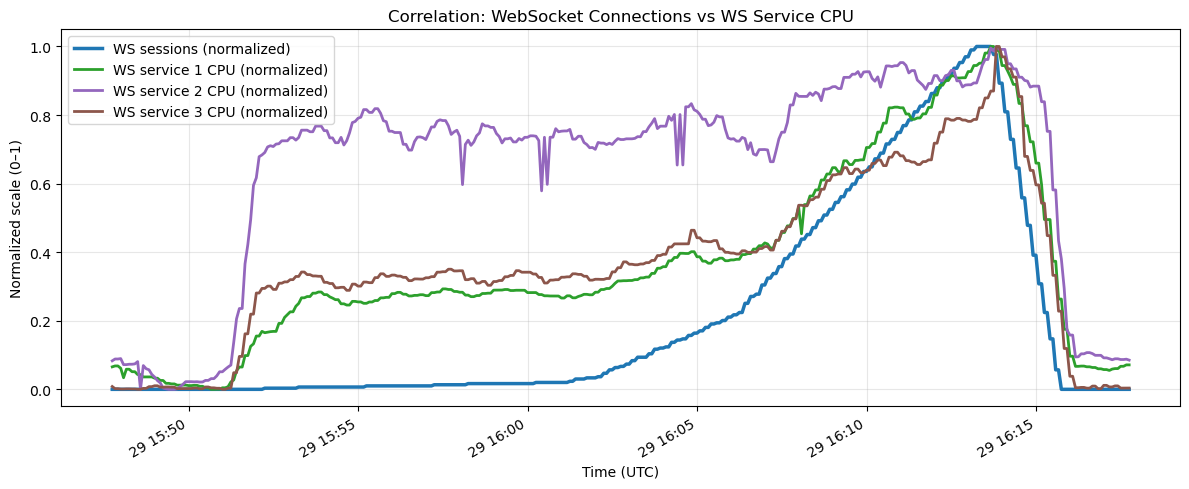

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))

if not ws_active_sessions.empty:
    normalize(ws_active_sessions).plot(
        ax=ax, linewidth=2.5, label="WS sessions (normalized)", color="tab:blue"
    )

if not ws_service_1_cpu.empty:
    normalize(ws_service_1_cpu).plot(
        ax=ax, linewidth=2.0, label="WS service 1 CPU (normalized)", color="tab:green"
    )

if not ws_service_2_cpu.empty:
    normalize(ws_service_2_cpu).plot(
        ax=ax, linewidth=2.0, label="WS service 2 CPU (normalized)", color="tab:purple"
    )

if not ws_service_3_cpu.empty:
    normalize(ws_service_3_cpu).plot(
        ax=ax, linewidth=2.0, label="WS service 3 CPU (normalized)", color="tab:brown"
    )

ax.set_title("Correlation: WebSocket Connections vs WS Service CPU")
ax.set_ylabel("Normalized scale (0–1)")
ax.set_xlabel("Time (UTC)")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

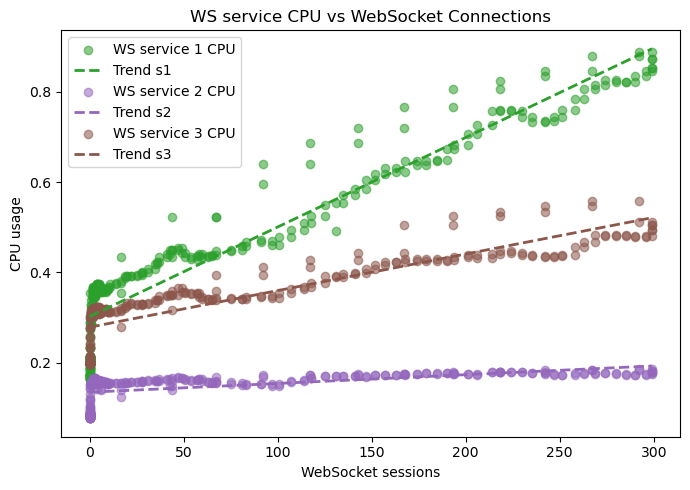

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))

x = ws_active_sessions.iloc[:, 0]

if not ws_service_1_cpu.empty:
    y1 = ws_service_1_cpu.reindex(x.index).iloc[:, 0]
    mask1 = ~(x.isna() | y1.isna())
    ax.scatter(x[mask1], y1[mask1], alpha=0.55, label="WS service 1 CPU", color="tab:green")
    if mask1.sum() > 1:
        z1 = np.polyfit(x[mask1], y1[mask1], 1)
        p1 = np.poly1d(z1)
        xs1 = np.linspace(x[mask1].min(), x[mask1].max(), 100)
        ax.plot(xs1, p1(xs1), linewidth=2, color="tab:green", linestyle="--", label="Trend s1")

if not ws_service_2_cpu.empty:
    y2 = ws_service_2_cpu.reindex(x.index).iloc[:, 0]
    mask2 = ~(x.isna() | y2.isna())
    ax.scatter(x[mask2], y2[mask2], alpha=0.55, label="WS service 2 CPU", color="tab:purple")
    if mask2.sum() > 1:
        z2 = np.polyfit(x[mask2], y2[mask2], 1)
        p2 = np.poly1d(z2)
        xs2 = np.linspace(x[mask2].min(), x[mask2].max(), 100)
        ax.plot(xs2, p2(xs2), linewidth=2, color="tab:purple", linestyle="--", label="Trend s2")

if not ws_service_3_cpu.empty:
    y3 = ws_service_3_cpu.reindex(x.index).iloc[:, 0]
    mask3 = ~(x.isna() | y3.isna())
    ax.scatter(x[mask3], y3[mask3], alpha=0.55, label="WS service 3 CPU", color="tab:brown")
    if mask3.sum() > 1:
        z3 = np.polyfit(x[mask3], y3[mask3], 1)
        p3 = np.poly1d(z3)
        xs3 = np.linspace(x[mask3].min(), x[mask3].max(), 100)
        ax.plot(xs3, p3(xs3), linewidth=2, color="tab:brown", linestyle="--", label="Trend s3")

ax.set_xlabel("WebSocket sessions")
ax.set_ylabel("CPU usage")
ax.set_title("WS service CPU vs WebSocket Connections")
ax.legend()

plt.tight_layout()
plt.show()

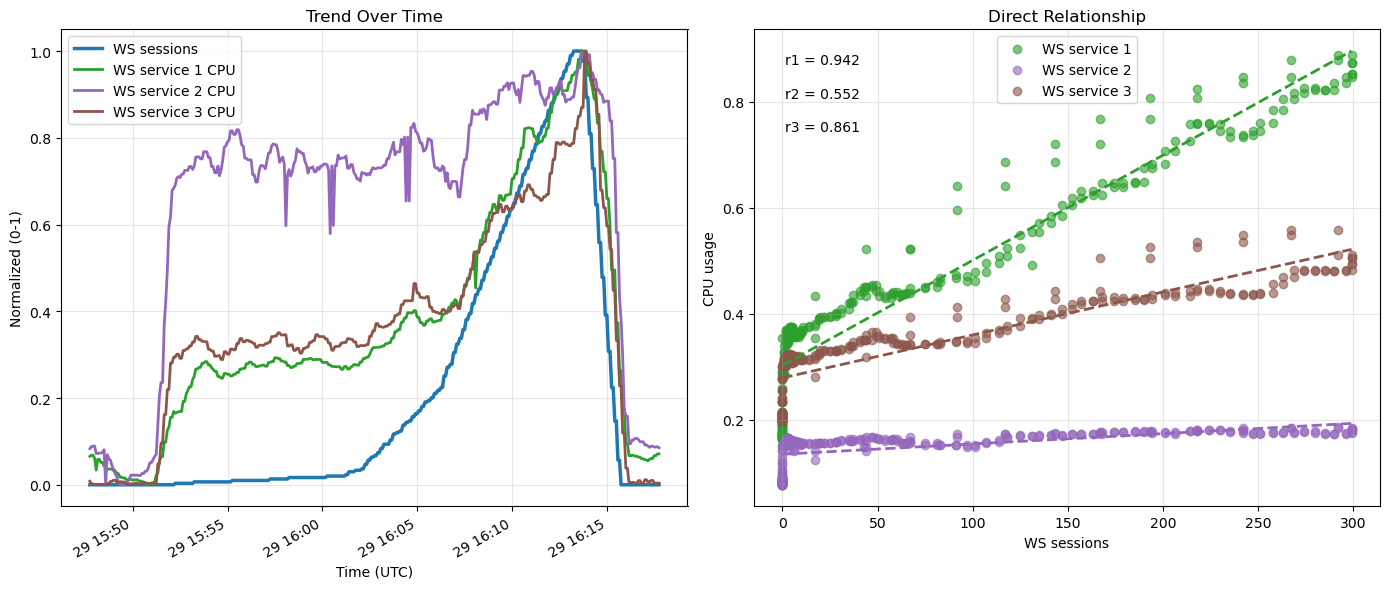

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- Left: normalized timeline ---
if not ws_active_sessions.empty:
    normalize(ws_active_sessions).plot(
        ax=ax1, linewidth=2.5, color="tab:blue", label="WS sessions"
    )

if not ws_service_1_cpu.empty:
    normalize(ws_service_1_cpu).plot(
        ax=ax1, linewidth=2.0, color="tab:green", label="WS service 1 CPU"
    )

if not ws_service_2_cpu.empty:
    normalize(ws_service_2_cpu).plot(
        ax=ax1, linewidth=2.0, color="tab:purple", label="WS service 2 CPU"
    )

if not ws_service_3_cpu.empty:
    normalize(ws_service_3_cpu).plot(
        ax=ax1, linewidth=2.0, color="tab:brown", label="WS service 3 CPU"
    )

ax1.set_title("Trend Over Time")
ax1.set_ylabel("Normalized (0-1)")
ax1.set_xlabel("Time (UTC)")
ax1.legend(frameon=True)
ax1.grid(True, alpha=0.3)

# --- Right: scatter ---
x = ws_active_sessions.iloc[:, 0]

if not ws_service_1_cpu.empty:
    y1 = ws_service_1_cpu.reindex(x.index).iloc[:, 0]
    m1 = ~(x.isna() | y1.isna())
    ax2.scatter(x[m1], y1[m1], alpha=0.6, color="tab:green", label="WS service 1")
    if m1.sum() > 1:
        z1 = np.polyfit(x[m1], y1[m1], 1)
        p1 = np.poly1d(z1)
        xs1 = np.linspace(x[m1].min(), x[m1].max(), 100)
        ax2.plot(xs1, p1(xs1), linewidth=2.0, color="tab:green", linestyle="--")
        r1 = np.corrcoef(x[m1], y1[m1])[0, 1]
        ax2.text(0.05, 0.95, f"r1 = {r1:.3f}", transform=ax2.transAxes, fontsize=10, verticalalignment="top")

if not ws_service_2_cpu.empty:
    y2 = ws_service_2_cpu.reindex(x.index).iloc[:, 0]
    m2 = ~(x.isna() | y2.isna())
    ax2.scatter(x[m2], y2[m2], alpha=0.6, color="tab:purple", label="WS service 2")
    if m2.sum() > 1:
        z2 = np.polyfit(x[m2], y2[m2], 1)
        p2 = np.poly1d(z2)
        xs2 = np.linspace(x[m2].min(), x[m2].max(), 100)
        ax2.plot(xs2, p2(xs2), linewidth=2.0, color="tab:purple", linestyle="--")
        r2 = np.corrcoef(x[m2], y2[m2])[0, 1]
        ax2.text(0.05, 0.88, f"r2 = {r2:.3f}", transform=ax2.transAxes, fontsize=10, verticalalignment="top")

if not ws_service_3_cpu.empty:
    y3 = ws_service_3_cpu.reindex(x.index).iloc[:, 0]
    m3 = ~(x.isna() | y3.isna())
    ax2.scatter(x[m3], y3[m3], alpha=0.6, color="tab:brown", label="WS service 3")
    if m3.sum() > 1:
        z3 = np.polyfit(x[m3], y3[m3], 1)
        p3 = np.poly1d(z3)
        xs3 = np.linspace(x[m3].min(), x[m3].max(), 100)
        ax2.plot(xs3, p3(xs3), linewidth=2.0, color="tab:brown", linestyle="--")
        r3 = np.corrcoef(x[m3], y3[m3])[0, 1]
        ax2.text(0.05, 0.81, f"r3 = {r3:.3f}", transform=ax2.transAxes, fontsize=10, verticalalignment="top")

ax2.set_title("Direct Relationship")
ax2.set_xlabel("WS sessions")
ax2.set_ylabel("CPU usage")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Simple graph: JVM CPU vs WS delivery latency

Uses `process_cpu_usage` (already loaded as `proc_cpu`) and k6 remote-write latency. **Set `WS_LAT_QUERY`** to the exact metric name from Prometheus (e.g. `k6_ws_delivery_latency_ms_avg` or `{__name__=~".*ws_delivery.*"}` in Explore).

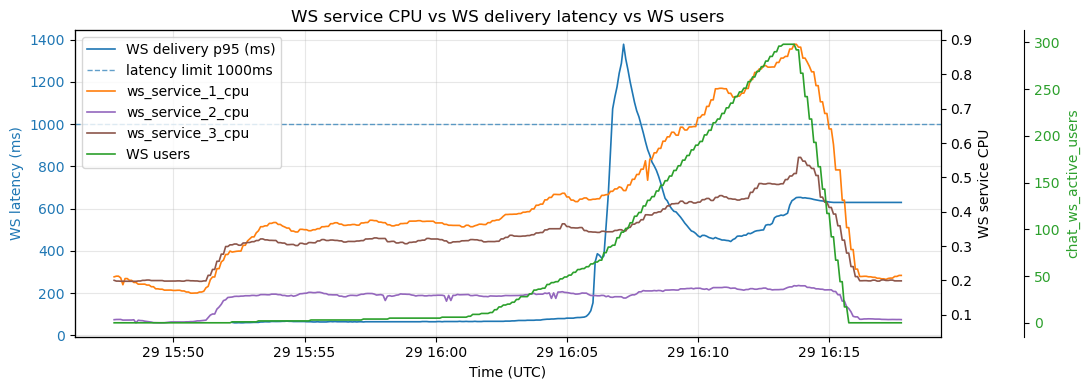

In [8]:
fig, ax1 = plt.subplots(figsize=(11, 4))

if not ws_lat.empty:
    s_lat = ws_lat.iloc[:, 0]
    ax1.plot(s_lat.index, s_lat.values, color="tab:blue", linewidth=1.2, label="WS delivery p95 (ms)")
ax1.set_ylabel("WS latency (ms)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.set_xlabel("Time (UTC)")
ax1.grid(True, alpha=0.3)
ax1.axhline(y=1000, color="tab:blue", linestyle="--", linewidth=1, alpha=0.7, label="latency limit 1000ms")

ax2 = ax1.twinx()
if not ws_service_1_cpu.empty:
    s1 = ws_service_1_cpu.iloc[:, 0]
    ax2.plot(s1.index, s1.values, color="tab:orange", linewidth=1.2, label="ws_service_1_cpu")
if not ws_service_2_cpu.empty:
    s2 = ws_service_2_cpu.iloc[:, 0]
    ax2.plot(s2.index, s2.values, color="tab:purple", linewidth=1.2, label="ws_service_2_cpu")
if not ws_service_3_cpu.empty:
    s3 = ws_service_3_cpu.iloc[:, 0]
    ax2.plot(s3.index, s3.values, color="tab:brown", linewidth=1.2, label="ws_service_3_cpu")
ax2.set_ylabel("WS service CPU")

ax3 = ax1.twinx()
ax3.spines["right"].set_position(("outward", 60))
if not ws_users.empty:
    s_users = ws_users.iloc[:, 0]
    ax3.plot(s_users.index, s_users.values, color="tab:green", linewidth=1.2, label="WS users")
ax3.set_ylabel("chat_ws_active_users", color="tab:green")
ax3.tick_params(axis="y", labelcolor="tab:green")

lines1, lab1 = ax1.get_legend_handles_labels()
lines2, lab2 = ax2.get_legend_handles_labels()
lines3, lab3 = ax3.get_legend_handles_labels()
ax1.legend(lines1 + lines2 + lines3, lab1 + lab2 + lab3, loc="upper left")
plt.title("WS service CPU vs WS delivery latency vs WS users")
plt.tight_layout()
plt.show()

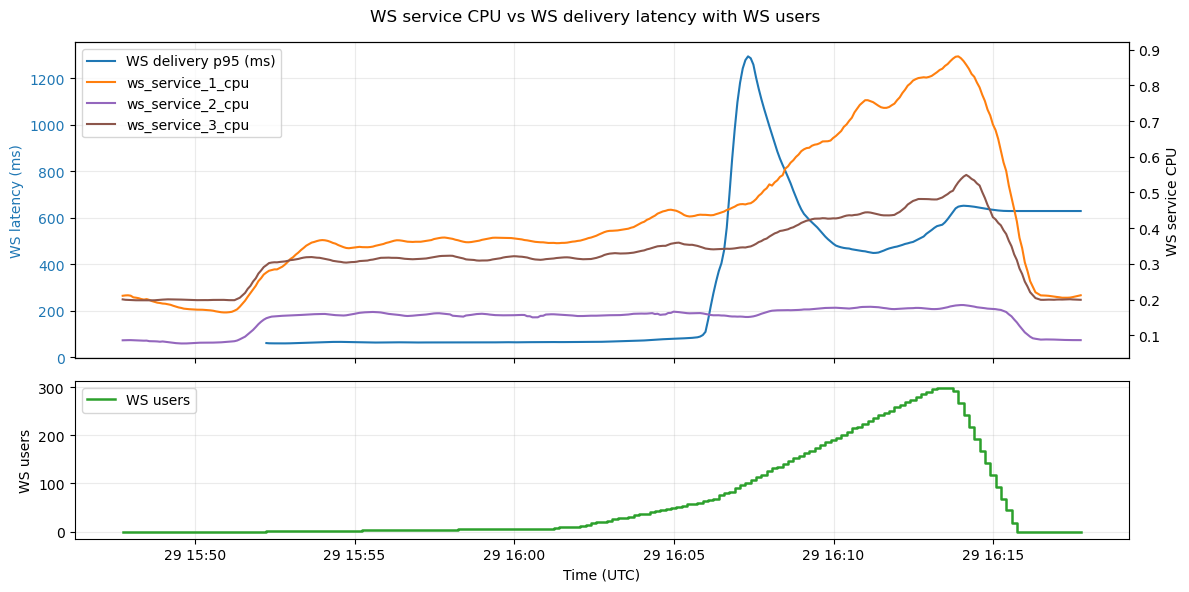

In [9]:
fig, (ax_top, ax_bottom) = plt.subplots(
    2, 1, figsize=(12, 6), sharex=True, gridspec_kw={"height_ratios": [2, 1]}
)

# Optional smoothing
lat = ws_lat.iloc[:, 0].rolling(5, min_periods=1).mean() if not ws_lat.empty else None
cpu1 = ws_service_1_cpu.iloc[:, 0].rolling(5, min_periods=1).mean() if not ws_service_1_cpu.empty else None
cpu2 = ws_service_2_cpu.iloc[:, 0].rolling(5, min_periods=1).mean() if not ws_service_2_cpu.empty else None
cpu3 = ws_service_3_cpu.iloc[:, 0].rolling(5, min_periods=1).mean() if not ws_service_3_cpu.empty else None
users = ws_users.iloc[:, 0] if not ws_users.empty else None

# Top: latency + WS service CPU
if lat is not None:
    ax_top.plot(lat.index, lat.values, color="tab:blue", lw=1.5, label="WS delivery p95 (ms)")
ax_top.set_ylabel("WS latency (ms)", color="tab:blue")
ax_top.tick_params(axis="y", labelcolor="tab:blue")
ax_top.grid(True, alpha=0.25)

ax_top_r = ax_top.twinx()
if cpu1 is not None:
    ax_top_r.plot(cpu1.index, cpu1.values, color="tab:orange", lw=1.5, label="ws_service_1_cpu")
if cpu2 is not None:
    ax_top_r.plot(cpu2.index, cpu2.values, color="tab:purple", lw=1.5, label="ws_service_2_cpu")
if cpu3 is not None:
    ax_top_r.plot(cpu3.index, cpu3.values, color="tab:brown", lw=1.5, label="ws_service_3_cpu")
ax_top_r.set_ylabel("WS service CPU")

# Merge top legends
l1, t1 = ax_top.get_legend_handles_labels()
l2, t2 = ax_top_r.get_legend_handles_labels()
ax_top.legend(l1 + l2, t1 + t2, loc="upper left")

# Bottom: users only
if users is not None:
    ax_bottom.plot(users.index, users.values, color="tab:green", lw=1.8, label="WS users", drawstyle="steps-post")
ax_bottom.set_ylabel("WS users")
ax_bottom.set_xlabel("Time (UTC)")
ax_bottom.grid(True, alpha=0.25)
ax_bottom.legend(loc="upper left")

fig.suptitle("WS service CPU vs WS delivery latency with WS users", y=0.98)
plt.tight_layout()
plt.show()